In [31]:
import pandas as pd
import numpy as np
import torch
import pyro
import pyro.distributions.constraints as constraints
import pyro.distributions as dist
import matplotlib.pyplot as plt
import seaborn as sns

dataset = pd.read_csv('data/rugged_data.csv', encoding='ISO-8859-1')
df = dataset[['rugged', 'cont_africa', 'rgdppc_2000']]
print(df.head())
print(df.describe())

   rugged  cont_africa  rgdppc_2000
0   0.462            0          NaN
1   2.518            0          NaN
2   0.858            1     1794.729
3   0.013            0          NaN
4   3.427            0     3703.113
           rugged  cont_africa   rgdppc_2000
count  234.000000   234.000000    170.000000
mean     1.375402     0.243590   9094.892853
std      1.370052     0.430168   9699.991472
min      0.000000     0.000000    466.647000
25%      0.376000     0.000000   1880.829250
50%      0.961500     0.000000   5314.742000
75%      1.981000     0.000000  13100.150000
max      7.811000     1.000000  57792.090000


In [32]:
df = df[np.isfinite(df.rgdppc_2000)]
df['rgdppc_2000'] = np.log(df['rgdppc_2000'])

In [33]:
train = torch.tensor(df.values, dtype=torch.float)
ruggedness, is_cont_africa, log_gdp = train[:, 0], train[:, 1], train[:, 2]

<Axes: xlabel='rugged', ylabel='rgdppc_2000'>

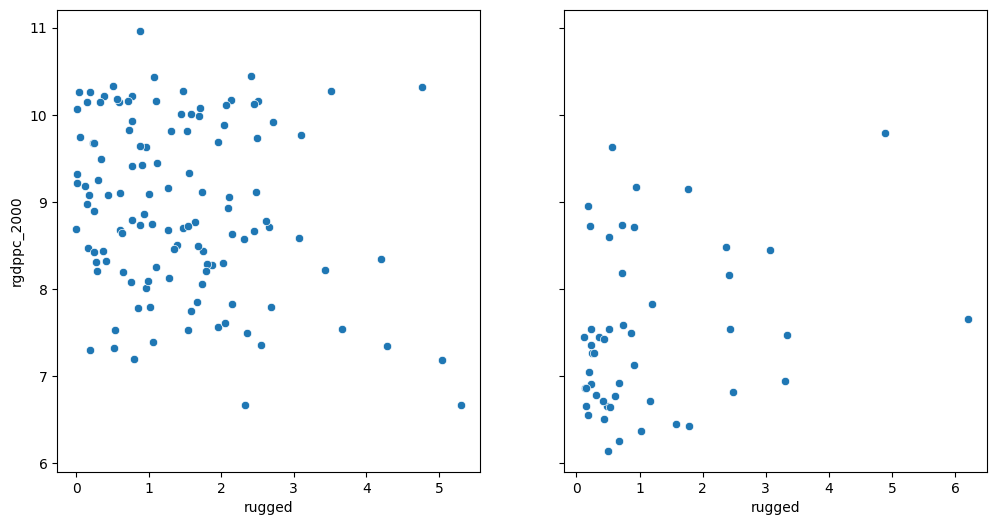

In [34]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,6), sharey=True)
african_nations = df[df['cont_africa'] == 1]
non_african_nations = df[df['cont_africa'] == 0]
sns.scatterplot(x=non_african_nations['rugged'], y=non_african_nations['rgdppc_2000'], ax=ax[0])
sns.scatterplot(x=african_nations['rugged'], y=african_nations['rgdppc_2000'], ax=ax[1])

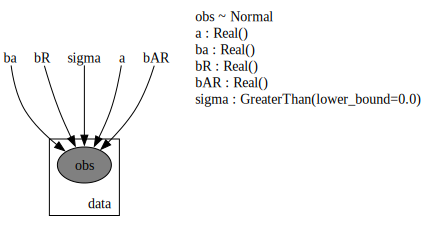

In [37]:
def simple_model(is_cont_africa, ruggedness, log_gdp):
    a = pyro.param('a', lambda: torch.randn(()))
    b_a = pyro.param('ba', lambda: torch.randn(()))
    b_r = pyro.param("bR", lambda: torch.randn(()))
    b_ar = pyro.param("bAR", lambda: torch.randn(()))
    sigma = pyro.param('sigma', lambda: torch.ones(()), constraint=constraints.positive)

    mean = a + b_a * is_cont_africa + b_r * ruggedness + b_ar * is_cont_africa * ruggedness

    with pyro.plate('data', len(ruggedness)):
        return pyro.sample('obs', dist.Normal(mean, sigma), obs=log_gdp)
    
pyro.render_model(simple_model, model_args=(is_cont_africa, ruggedness, log_gdp), render_distributions=True)
pyro.render_model(simple_model, model_args=(is_cont_africa, ruggedness, log_gdp), render_distributions=True, render_params=True)